## Task: Predict Food Delivery Time

You are provided with a food delivery dataset that includes features such as delivery distance, restaurant preparation time, traffic conditions, and order details. Your objective is to develop a regression model that accurately predicts the delivery time in minutes.

Your target is the column: "delivery_time".

You are provided with the code to download and load the csv file.

Your work will be evaluated based on the completion of the following tasks:


# Part 1: Read Data

**Tasks:**

1. Read the dataset `Q1_data.csv` using `read_csv()`
2. Inspect the first few rows using `head()`
3. Display dataset information using `info()`
4. Show statistical description using `describe()`
5. Plot the target distribution (delivery_time)

In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')



In [136]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammad2012191/q1-ka-ai-2026")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'q1-ka-ai-2026' dataset.
Path to dataset files: /kaggle/input/q1-ka-ai-2026


In [137]:
# Task 1: Write your code here:
df_path = os.path.join(path, 'Q1_data.csv')
df = pd.read_csv(df_path)

print(f"Dataset shape: {df.shape}")

Dataset shape: (1663, 9)


In [138]:
# Task 2: Write your code here:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43.0
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84.0
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59.0
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37.0
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68.0


In [139]:
# Task 3: Write your code here:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1663 entries, 0 to 1662
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1663 non-null   int64  
 1   Distance_km             1663 non-null   float64
 2   Weather                 1608 non-null   object 
 3   Traffic_Level           1612 non-null   object 
 4   Time_of_Day             1613 non-null   object 
 5   Vehicle_Type            1663 non-null   object 
 6   Preparation_Time_min    1663 non-null   int64  
 7   Courier_Experience_yrs  1614 non-null   float64
 8   Delivery_Time           1557 non-null   float64
dtypes: float64(3), int64(2), object(4)
memory usage: 117.1+ KB


In [140]:
# Task 4: Write your code here:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time
count,1663.000000,1663.000000,1663.000000,1614.000000,1557.000000
mean,495.866506,10.049910,17.038485,4.586741,56.640976
std,289.514088,5.684406,7.230498,2.916843,22.135919
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,246.500000,5.130000,11.000000,2.000000,41.000000
50%,490.000000,10.160000,17.000000,5.000000,55.000000
75%,745.500000,14.980000,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


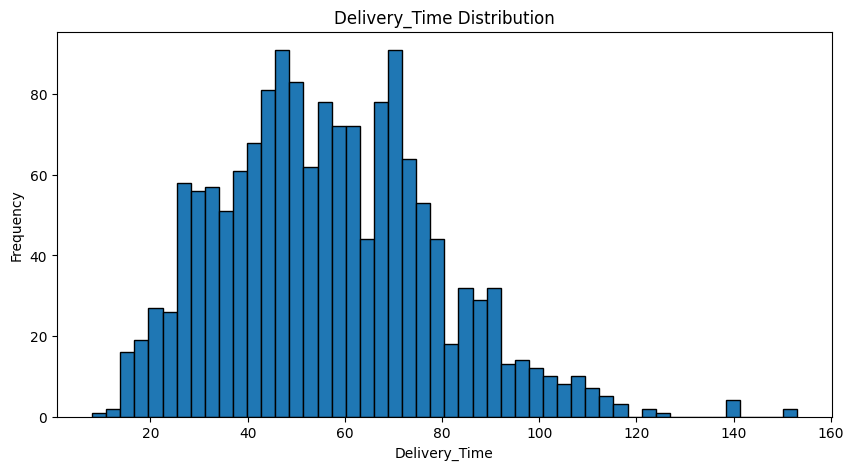

In [141]:
# Task 5: Write your code here:

plt.figure(figsize=(10, 5))
plt.hist(df['Delivery_Time'].dropna(), bins=50, edgecolor='black')
plt.title('Delivery_Time Distribution')
plt.xlabel('Delivery_Time')
plt.ylabel('Frequency')
plt.show()

# Part 2: Data Cleaning

**Tasks:**

Inspect and fix the following when needed:

1. **Drop the 'Order_ID' column from the data**
2. **Handle missing values appropriately** (Hint: I guess you want to have a closer look at the columns with missing values :) )
3. **Check and remove duplicates** if any exist
4. **Encode categorical variables** if needed (Bonus if used One Hot Encoding)
5. **Apply feature scaling for all features** (Use StandardScaler)
6. **Check for target imbalance and state if it is imbalanced or not** (keep this cell empty if not needed)

In [142]:
# Task 1: Write your code here:

df = df.drop(['Order_ID'], axis=1)
df.head()


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43.0
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84.0
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59.0
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37.0
4,19.03,Clear,Low,Morning,Bike,16,5.0,68.0


In [143]:
# Task 2: Write your code here:

missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_data = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing_Percentage': missing_percentage.values
})
missing_data = missing_data[missing_data['Missing_Percentage'] > 0].sort_values('Missing_Percentage', ascending=False)

print("Missing Data Analysis:")
missing_data.head(10)

Missing Data Analysis:


,Column,Missing_Percentage
7,Delivery_Time,6.374023
1,Weather,3.307276
2,Traffic_Level,3.066747
3,Time_of_Day,3.006615
6,Courier_Experience_yrs,2.946482


In [144]:
# Define stat columns
stat_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time']
print(f"Shape before cleaning: {df.shape}")

# Drop rows with missing stat values
df_clean = df.dropna(subset=stat_cols).copy()
print(f"Shape after cleaning: {df_clean.shape}")

Shape before cleaning: (1663, 8)
Shape after cleaning: (1512, 8)


In [145]:
# Fill categorical columns with 'unknown' - missing likely means "not specified"
for col in ['Weather', 'Time_of_Day']:
    df_clean[col] = df_clean[col].fillna('unknown')

# Fill columns with mode - discrete feature, mode is most representative
for col in ['Traffic_Level', 'Vehicle_Type']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values remaining:", df_clean.isnull().sum().sum())

Missing values remaining: 0


In [146]:
df_clean.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43.0
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84.0
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59.0
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37.0
4,19.03,Clear,Low,Morning,Bike,16,5.0,68.0


In [147]:
# Task 3: Write your code here:

def check_duplicates(df):
  duplicates = df_clean.duplicated().sum()
  print(f"Number of Duplicate Samples: {duplicates}")
  if duplicates > 0:
    print("Dropping Duplicates...")
    df_clean.drop_duplicates(inplace=True)
    print("Duplicates Dropped.")
  else:
    print("No Duplicate Samples Found.")

check_duplicates(df_clean)

Number of Duplicate Samples: 542
Dropping Duplicates...
Duplicates Dropped.


In [148]:
# Task 4: Write your code here:

categorical_cols = ['Weather',	'Traffic_Level',	'Time_of_Day',	'Vehicle_Type']
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

df_clean.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time
0,7.93,4,1,0,2,12,1.0,43.0
1,16.42,0,2,1,0,20,2.0,84.0
2,9.52,1,1,3,2,28,1.0,59.0
3,7.44,2,2,0,2,5,1.0,37.0
4,19.03,0,1,2,0,16,5.0,68.0


In [149]:
# Task 5: Write your code here:
from sklearn.preprocessing import StandardScaler

features = df_clean.columns.drop("Delivery_Time")  # DON'T SCALE THE TARGET

scaler = StandardScaler()
df_clean[features] = scaler.fit_transform(df_clean[features])
df_clean.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time
0,-0.373372,1.755928,-0.296970,-1.210219,1.380865,-0.695598,-1.228807,43.0
1,1.119836,-0.882724,1.030501,-0.267317,-0.912695,0.415755,-0.885506,84.0
2,-0.093725,-0.223061,-0.296970,1.618486,1.380865,1.527107,-1.228807,59.0
3,-0.459552,0.436602,1.030501,-1.210219,1.380865,-1.668031,-1.228807,37.0
4,1.578879,-0.882724,-0.296970,0.675584,-0.912695,-0.139922,0.144399,68.0


In [150]:
# Task 6: Write your code here:

# As we have seen in the Part1 Task 5 our target distribution already so we dont want to plot the same thing again. we have seen skeweness of our data.

# Part 3: Modeling

**Tasks:**

1. Split the dataset into features (X) and target (y)
2. Use the correct split: **KFold** OR **StratifiedKFold**
3. Train a **RandomForest** model
4. Evaluate using **MAE (Mean Absolute Error) ONLY**
5. Print the averaged score across all folds

In [164]:
# Task 1: Write your code here:
X = df_clean.drop("Delivery_Time", axis=1)
y = df_clean['Delivery_Time']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [165]:
# Task 2,3,4,5: Write your code here:

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error as sklearn_mse, mean_absolute_error, r2_score

models = {"Random Forest Regressor": RandomForestRegressor(n_estimators=200)}

# Storage for results
all_results = {}

for name in models:
  all_results[name] = {'mae': []}

In [170]:
n_splits =5
kf = KFold(n_splits, shuffle=True, random_state=42)

for fold_idx, (train_index, test_index) in enumerate(kf.split(X)):
  print(f"\nFold {fold_idx + 1}/{n_splits}")

  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)

    # Store results
    all_results[mean_absolute_error]["mae"].append(mae)


In [ ]:
for model_name in all_results:
  print(f"\n{model_name}:")
  print(f"  MAE:  {np.mean(all_results[model_name]['mae']):.4f}")

# Part 4: Plots

**Tasks:**

1. Plot feature importance from your trained model
2. Plot predicted delivery time histogram

In [ ]:
# Task 1: Write your code here:

feature_cols = df_clean.drop("Delivery_Time", axis=1)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Task 2: Write your code here:


# Part 5: Bonus - Ensemble

**Task:**

Why use one model? Let's use 2 then merge!

Rewrite the KFold loop such that you:
1. Train **2 different models** inside the loop at the same time in each iteration
2. Average their predictions
3. Calculate the MAE metric on the averaged predictions

Use RandomForestRegressor and CatBoostRegressor.

In [ ]:
# Task Bonus: Write your code here:
from sklearn.ensemble import CatBoostRegressor

models = {"Random Forest Regressor": RandomForestRegressor(n_estimators=200),
          "CatBoost": CatBoostRegressor(verbose=0)}

# Storage for results
all_results = {}

for name in models:
  all_results[name] = {'mae': []}

In [ ]:
n_splits =5
kf = KFold(n_splits, shuffle=True, random_state=42)

for fold_idx, (train_index, test_index) in enumerate(kf.split(X)):
  print(f"\nFold {fold_idx + 1}/{n_splits}")

  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)


    # Store results
    all_results[mean_absolute_error]["mae"].append(mae)

In [ ]:
for model_name in all_results:
  print(f"\n{model_name}:")
  print(f"  MAE:  {np.mean(all_results[model_name]['mae']):.4f}")
